# Project 1
# Marwa Alameddine

# Task

In 1995 Kohavi and Becker extracted and cleaned this data from the 1994 US Census. It went on to be used as a benchmark dataset for many papers. In this project, we will work with this dataset to explore patterns of income and consider how time and location may alter or confound these relationships. 

# Data load

In [161]:
import pandas as pd

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

df = pd.read_csv(
    "adult.data",
    header=None,
    names=columns
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [162]:
df_test = pd.read_csv(
    "adult.test",
    header=None,
    names=columns,
    skiprows=1
)

df_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


# Data Exploration

## 1. Data Types

In [163]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


The dataset includes both numerical and categorical variables. Columns like age, fnlwgt, education_num, capital_gain, capital_loss, and hours_per_week are numerical and are stored as integers. The rest of the columns are categorical and are stored as strings. The data types seem appropriate and match what is expected from the dataset description.

## 2. Missing Values

In [164]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [165]:
(df == " ?").sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [166]:
(df_test == " ?").sum()

age                 0
workclass         963
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        966
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    274
income              0
dtype: int64

In [167]:
import numpy as np
df = df_raw.replace(" ?", np.nan)
df_test = df_test.replace(" ?", np.nan)

In [168]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [169]:
df_test.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        966
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    274
income              0
dtype: int64

Missing values in the dataset are represented as " ?". They were converted to NaN using the replace() function. After this conversion, the number of missing values in each column was computed using isnull().
Train data:
Workclass: 1836
Occupation: 1843
Native_country: 583
Test data:
Workclass: 963
Occupation: 966
Native_country: 274

## 3. Distribution of capital_gain and capital_loss

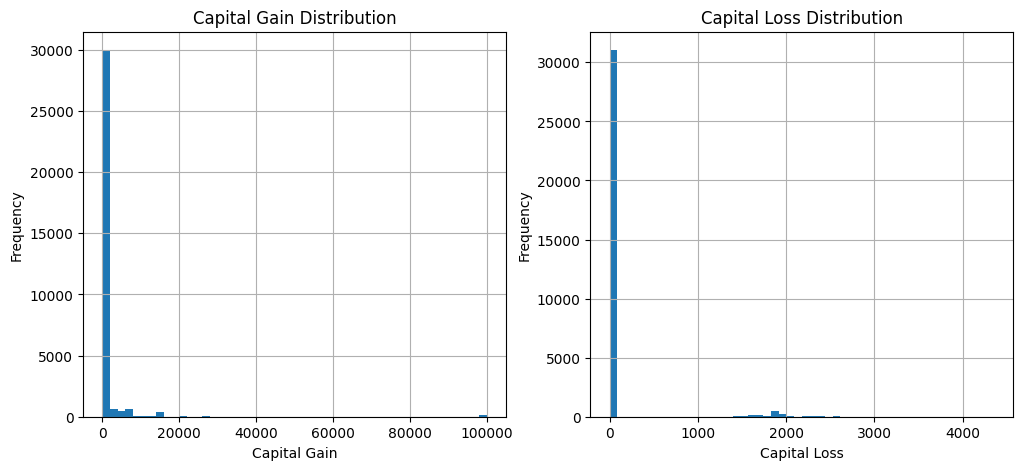

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df["capital_gain"].hist(bins=50)
plt.title("Capital Gain Distribution")
plt.xlabel("Capital Gain")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
df["capital_loss"].hist(bins=50)
plt.title("Capital Loss Distribution")
plt.xlabel("Capital Loss")
plt.ylabel("Frequency")

plt.show()

The distributions of capital_gain and capital_loss are highly skewed to the right. Most values are 0, and only a small number of people have positive values. This shows that the majority of individuals do not have any capital gains or losses, while only a few have noticeable amounts. Because of this, it might be more useful to convert these variables into categorical ones that indicate whether a person has any gain or loss, instead of focusing on the exact values.

In [171]:
df["has_capital_gain"] = (df["capital_gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital_loss"] > 0).astype(int)

In [172]:
df["has_capital_gain"].value_counts()

has_capital_gain
0    29849
1     2712
Name: count, dtype: int64

In [173]:
df["has_capital_loss"].value_counts()

has_capital_loss
0    31042
1     1519
Name: count, dtype: int64

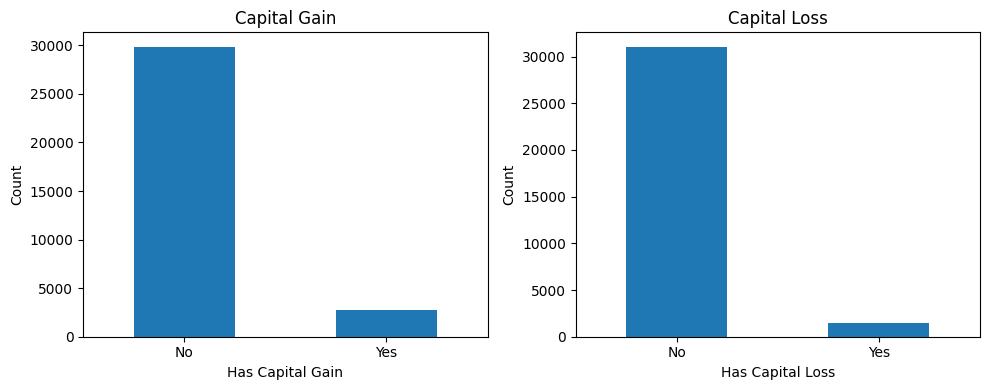

In [174]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df["has_capital_gain"].value_counts().rename({0: "No", 1: "Yes"}).plot(kind="bar")
plt.title("Capital Gain")
plt.xlabel("Has Capital Gain")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.subplot(1,2,2)
df["has_capital_loss"].value_counts().rename({0: "No", 1: "Yes"}).plot(kind="bar")
plt.title("Capital Loss")
plt.xlabel("Has Capital Loss")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. fnlwgt

In [175]:
df["fnlwgt"].describe()

count    3.256100e+04
mean     1.897784e+05
std      1.055500e+05
min      1.228500e+04
25%      1.178270e+05
50%      1.783560e+05
75%      2.370510e+05
max      1.484705e+06
Name: fnlwgt, dtype: float64

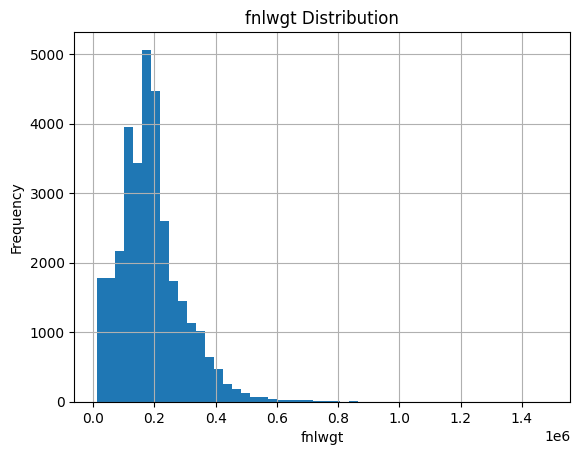

In [176]:
df["fnlwgt"].hist(bins=50)
plt.title("fnlwgt Distribution")
plt.xlabel("fnlwgt")
plt.ylabel("Frequency")
plt.show()

The distribution of fnlwgt is right-skewed, with most values concentrated at lower ranges and a long tail extending to higher values. This indicates that the variable is not symmetrically distributed. The presence of very large maximum values compared to the median suggests that there are potential outliers in the data.

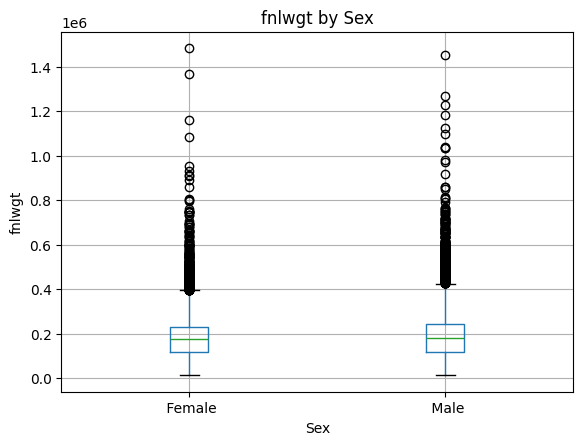

In [177]:
df.boxplot(column="fnlwgt", by="sex")
plt.title("fnlwgt by Sex")
plt.suptitle("")
plt.xlabel("Sex")
plt.ylabel("fnlwgt")
plt.show()

In [178]:
df.groupby("sex")["fnlwgt"].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Female,10771.0,185746.311206,102986.078821,12285.0,117363.00,176077.0,228331.50,1484705.0
Male,21790.0,191771.449013,106740.702676,13769.0,118200.75,180140.0,241146.25,1455435.0


The fnlwgt values are not symmetrically distributed and are clearly pushed to the right side(skewed toward higher values), with many large values appearing. When comparing males and females, the distribution is very similar, with close medians and spreads. This is also supported by the summary statistics, where the mean is higher than the median for both groups, confirming the right-skewed distribution. There are many points outside the boxplot, indicating the presence of outliers, but this is expected since fnlwgt represents sampling weights, where some small groups receive larger weights. For this reason, the outliers were kept in the analysis.

## 5. Linear Regression

In [179]:
df["sex_binary"] = df["sex"].str.strip().map({"Male": 1, "Female": 0})

In [180]:
from sklearn.linear_model import LinearRegression

X = df[["sex_binary"]]
y = df["hours_per_week"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 36.41036115495342
Coefficient: 6.017725123155651


A linear regression model was fitted using hours_per_week as the dependent variable and sex as the independent variable. The coefficient for sex is positive, males tend to work more hours than females. On average, males work about 6 more hours per week compared to females.

## 6. Analysis

In [181]:
X2 = df[["sex_binary", "education_num"]]
y = df["hours_per_week"]

model2 = LinearRegression()
model2.fit(X2, y)

print("Intercept:", model2.intercept_)
print("Coefficients:", model2.coef_)

Intercept: 29.410571749078702
Coefficients: [5.97089097 0.69748584]


In [182]:
# statsmodels for significance
import statsmodels.api as sm

X2_sm = sm.add_constant(X2)
model2_sm = sm.OLS(y, X2_sm).fit()

print(model2_sm.summary())

                            OLS Regression Results                            
Dep. Variable:         hours_per_week   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     1295.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:09:12   Log-Likelihood:            -1.2680e+05
No. Observations:               32561   AIC:                         2.536e+05
Df Residuals:                   32558   BIC:                         2.536e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            29.4106      0.281    104.556

After adding education_num as a control variable, the effect of sex remains positive, males still work more hours than females (about 5.97 hours more per week). The coefficient for education_num is also positive (around 0.70), people with higher education tend to work slightly more hours per week. The p-value for education_num is very small (p < 0.05), so it is statistically significant. Overall, education has an effect, but it does not remove the difference between males and females.

In [183]:
df["income_binary"] = df["income"].str.strip().map({"<=50K": 0, ">50K": 1})

In [184]:
X3 = df[["sex_binary", "education_num", "income_binary"]]

model3 = LinearRegression()
model3.fit(X3, y)

print("Intercept:", model3.intercept_)
print("Coefficients:", model3.coef_)

Intercept: 31.42178934163281
Coefficients: [5.10098785 0.44780818 4.51745657]


In [185]:
# statsmodels for significance (Model 3)
import statsmodels.api as sm

X3_sm = sm.add_constant(X3)
model3_sm = sm.OLS(y, X3_sm).fit()

print(model3_sm.summary())

                            OLS Regression Results                            
Dep. Variable:         hours_per_week   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     1130.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:09:32   Log-Likelihood:            -1.2643e+05
No. Observations:               32561   AIC:                         2.529e+05
Df Residuals:                   32557   BIC:                         2.529e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            31.4218      0.288    109.184

In [186]:
print("Model 1 R^2:", model.score(X, y))
print("Model 2 R^2:", model2.score(X2, y))
print("Model 3 R^2:", model3.score(X3, y))

Model 1 R^2: 0.05258268582717074
Model 2 R^2: 0.07369993753726667
Model 3 R^2: 0.09432456747239681


This model includes sex, education, and income together. The intercept is just the baseline (a female with low income and zero education), which is around 31.4 hours per week. The coefficient for sex is about 5.1, so even after controlling for the other variables, men still work around 5 more hours than women. The education coefficient is positive but small (around 0.45), so more education slightly increases working hours, but not by much. The income coefficient is also positive (around 4.5), meaning people earning more than 50K tend to work more hours. All variables are statistically significant (p < 0.05), so they do have an effect. Overall, they explain part of what’s going on, but there are still other factors affecting working hours.

To decide which model is the best, I used the R² (R-squared) statistic. R² measures how much variation in the dependent variable is explained by the model, where a higher value indicates a better fit.

When I compare the three models, the R² increases each time a new variable is added. The first model, which includes only gender, explains about 5.3% of the variation in working hours. Adding education raises it to around 7.4%, and including income increases it further to about 9.4%. This shows that each variable helps improve the model, even though the overall explained variation is still relatively low. Model 3 is the best, since it includes all three variables and performs the best.

# Correlation

In [187]:
df[["age", "education_num", "hours_per_week"]].corr()

,age,education_num,hours_per_week
age,1.000000,0.036527,0.068756
education_num,0.036527,1.000000,0.148123
hours_per_week,0.068756,0.148123,1.000000


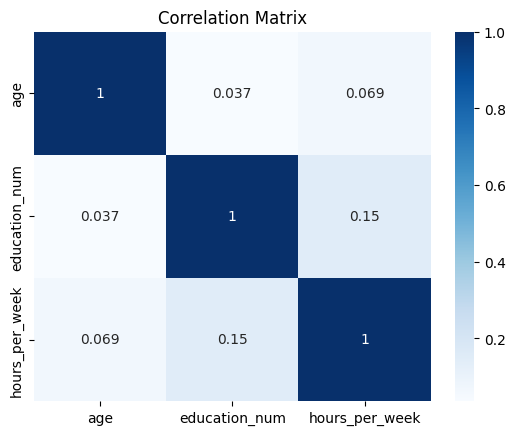

In [188]:
import seaborn as sns

corr_matrix = df[["age", "education_num", "hours_per_week"]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

## 1. Correlation

The correlation matrix shows that most of the relationships between the variables are weak. The correlation between age and education_num (0.036) and between age and hours_per_week (0.069) are both very small, indicating almost no relationship.

However, education_num and hours_per_week have a slightly higher positive correlation (0.148), which suggests that people with higher education tend to work a bit more hours.

Overall, none of the variables are strongly correlated, but there is a weak relationship between education and working hours.

## 2. Significance test

In [189]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["education_num"], df["hours_per_week"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.14812273262291162
P-value: 4.2366474790097093e-159


The correlation between education_num and hours_per_week was tested for statistical significance. The p-value is extremely small (much less than 0.05), so I reject the null hypothesis. This means the relationship is statistically significant and not due to random chance. However, the correlation itself is relatively weak (around 0.15), so the relationship exists but is not very strong. Basically, people with higher education levels tend to work slightly more hours, but the relationship is not very strong.

## 3. Correlation between education_num and age

In [190]:
df["sex"] = df["sex"].str.strip()

male = df[df["sex"] == "Male"]
female = df[df["sex"] == "Female"]

# Correlation + p-value
corr_male, pval_male = pearsonr(male["age"], male["education_num"])
corr_female, pval_female = pearsonr(female["age"], female["education_num"])

print("Male correlation:", round(corr_male, 4), "| p-value:", pval_male, "| n =", len(male))
print("Female correlation:", round(corr_female, 4), "| p-value:", pval_female, "| n =", len(female))

Male correlation: 0.0605 | p-value: 4.0229868301393892e-19 | n = 21790
Female correlation: -0.0179 | p-value: 0.06322895030880532 | n = 10771


After splitting the data, we can see that the correlation between education_num and age for males is very weak and positive (around 0.06), but it is statistically significant, likely because the sample size is large. For females, the correlation is almost zero and slightly negative (-0.018), and it is not statistically significant (p > 0.05). 
Overall, both correlations are very weak, which shows that there is basically no real relationship between age and education. This makes sense, since education level is usually fixed earlier in life and does not depend much on age.

## 4. Covariance matrix

In [191]:
df[["education_num", "hours_per_week"]].cov()

,education_num,hours_per_week
education_num,6.618890,4.705338
hours_per_week,4.705338,152.458995


The covariance matrix shows that the covariance between education_num and hours_per_week is positive (around 4.7), which means the two variables tend to increase together. The variance of education_num is relatively small (around 6.6) since its values only range from 1 to 16, while the variance of hours_per_week is much larger (around 152). This is expected because variance is in squared units and working hours vary more. If we take the square root, it’s around 12 hours, meaning people are around (+ or -) 12 hours from the average work week. Overall, the relationship is positive but still weak, which matches what we saw in the correlation.